In [3]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Parameters mirroring the Kaggle vgsales dataset
n_samples = 500
platforms = ['PS', 'PS2', 'PS3', 'PS4', 'XB', 'X360', 'XOne', 'Wii', 'NES', 'DS', '3DS', 'PC']
genres = ['Action', 'Shooter', 'Role-Playing', 'Sports', 'Platform', 'Racing', 'Misc', 'Fighting']
publishers = [
    'Nintendo', 'Electronic Arts', 'Activision', 'Sony Computer Entertainment',
    'Ubisoft', 'Take-Two Interactive', 'Capcom', 'Sega', 'Bandai Namco Entertainment'
]

# Sample game title generators
prefixes = ['Super', 'Grand', 'Call of', 'The Legend of', 'Final', 'Halo', 'Mario', 'World of']
nouns = ['Quest', 'Duty', 'Warfare', 'Kart', 'Fantasy', 'Adventure', 'Legacy', 'Combat']

titles = [
    f"{np.random.choice(prefixes)} {np.random.choice(nouns)} {i}" 
    for i in range(1, n_samples + 1)
]

# Generate synthetic sales and metadata
years = np.random.randint(1980, 2017, size=n_samples)
na_sales = np.round(np.random.exponential(scale=0.8, size=n_samples), 2)
eu_sales = np.round(np.random.exponential(scale=0.5, size=n_samples), 2)
jp_sales = np.round(np.random.exponential(scale=0.3, size=n_samples), 2)
other_sales = np.round(np.random.exponential(scale=0.15, size=n_samples), 2)
global_sales = np.round(na_sales + eu_sales + jp_sales + other_sales, 2)

# Build DataFrame
df_mock = pd.DataFrame({
    'Rank': range(1, n_samples + 1),
    'Name': titles,
    'Platform': np.random.choice(platforms, size=n_samples),
    'Year': years,
    'Genre': np.random.choice(genres, size=n_samples),
    'Publisher': np.random.choice(publishers, size=n_samples),
    'NA_Sales': na_sales,
    'EU_Sales': eu_sales,
    'JP_Sales': jp_sales,
    'Other_Sales': other_sales,
    'Global_Sales': global_sales
})

# Sort by Global_Sales descending to assign realistic ranks
df_mock = df_mock.sort_values(by='Global_Sales', ascending=False).reset_index(drop=True)
df_mock['Rank'] = df_mock.index + 1

# Export to CSV
df_mock.to_csv('vgsales.csv', index=False)
print("vgsales.csv created successfully with 500 records.")

vgsales.csv created successfully with 500 records.


In [4]:
# Read the saved CSV file
df = pd.read_csv(r'C:\Users\2k-tech\Data Analyst\Project 6\vgsales.csv')

# Display basic info and first few rows
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          500 non-null    int64  
 1   Name          500 non-null    object 
 2   Platform      500 non-null    object 
 3   Year          500 non-null    int64  
 4   Genre         500 non-null    object 
 5   Publisher     500 non-null    object 
 6   NA_Sales      500 non-null    float64
 7   EU_Sales      500 non-null    float64
 8   JP_Sales      500 non-null    float64
 9   Other_Sales   500 non-null    float64
 10  Global_Sales  500 non-null    float64
dtypes: float64(5), int64(2), object(4)
memory usage: 43.1+ KB
None


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Halo Warfare 286,Wii,1993,Fighting,Ubisoft,4.68,0.53,0.72,0.05,5.98
1,2,Super Adventure 131,XB,1993,Misc,Sony Computer Entertainment,4.95,0.13,0.57,0.01,5.66
2,3,The Legend of Quest 410,DS,1992,Racing,Bandai Namco Entertainment,4.49,0.69,0.35,0.05,5.58
3,4,Mario Adventure 425,XB,2007,Misc,Capcom,3.52,1.09,0.27,0.12,5.00
4,5,World of Fantasy 161,XOne,2004,Platform,Activision,2.32,2.20,0.23,0.13,4.88


In [5]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
print("Top Publishers by Total Global Sales:")
print(top_publishers)

Top Publishers by Total Global Sales:
Publisher
Sega                           131.77
Capcom                         108.82
Take-Two Interactive            99.96
Bandai Namco Entertainment      97.94
Activision                      96.38
Nintendo                        95.98
Ubisoft                         95.96
Sony Computer Entertainment     85.66
Electronic Arts                 76.10
Name: Global_Sales, dtype: float64


<Axes: title={'center': 'Sales by Genre and Region'}, xlabel='Genre'>

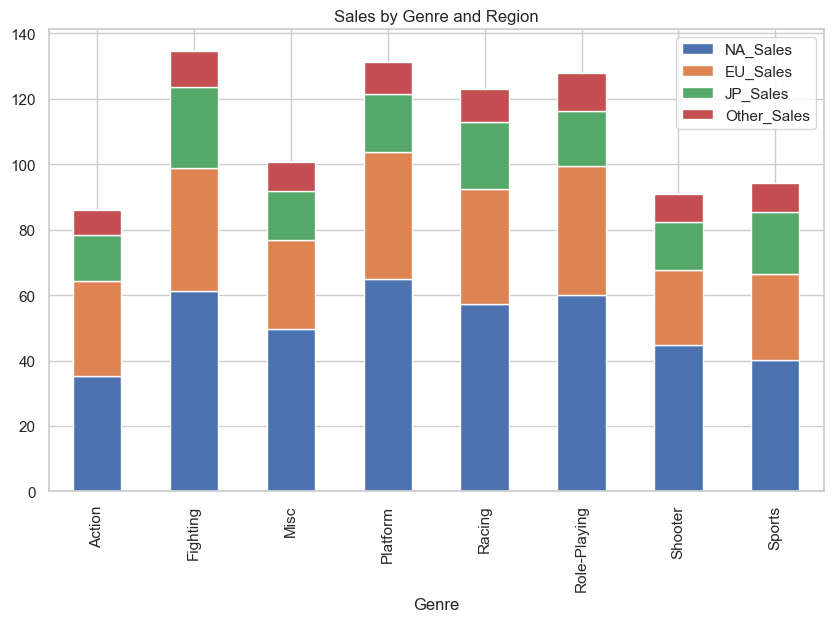

In [6]:
genre_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
genre_sales.plot(kind='bar', stacked=True, figsize=(10, 6), title='Sales by Genre and Region')

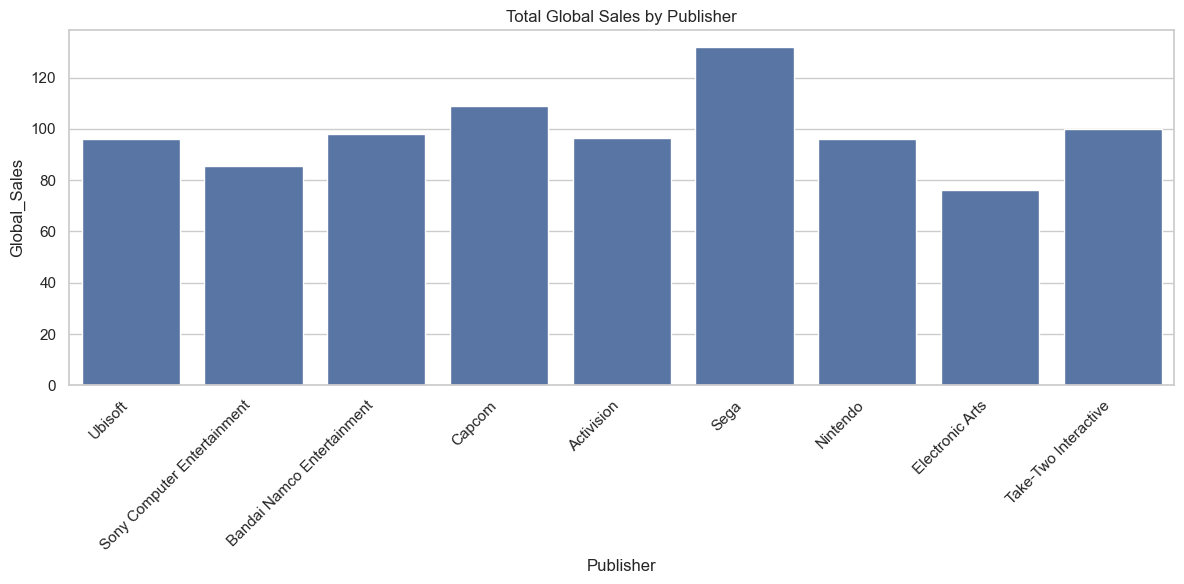

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Publisher', y='Global_Sales', estimator=sum, errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Total Global Sales by Publisher')
plt.tight_layout()
plt.show()

In [9]:
top_games = df.sort_values(by='Global_Sales', ascending=False).head(10)
top_games[['Name', 'Platform', 'Publisher', 'Genre', 'Global_Sales']]

,Name,Platform,Publisher,Genre,Global_Sales
0,Halo Warfare 286,Wii,Ubisoft,Fighting,5.98
1,Super Adventure 131,XB,Sony Computer Entertainment,Misc,5.66
2,The Legend of Quest 410,DS,Bandai Namco Entertainment,Racing,5.58
3,Mario Adventure 425,XB,Capcom,Misc,5.00
4,World of Fantasy 161,XOne,Activision,Platform,4.88
5,The Legend of Quest 181,XB,Sega,Platform,4.73
6,Call of Warfare 89,PS,Sega,Platform,4.67
7,World of Combat 165,PS4,Ubisoft,Misc,4.62
8,The Legend of Combat 9,XB,Nintendo,Action,4.54
9,World of Adventure 88,PS,Bandai Namco Entertainment,Platform,4.49


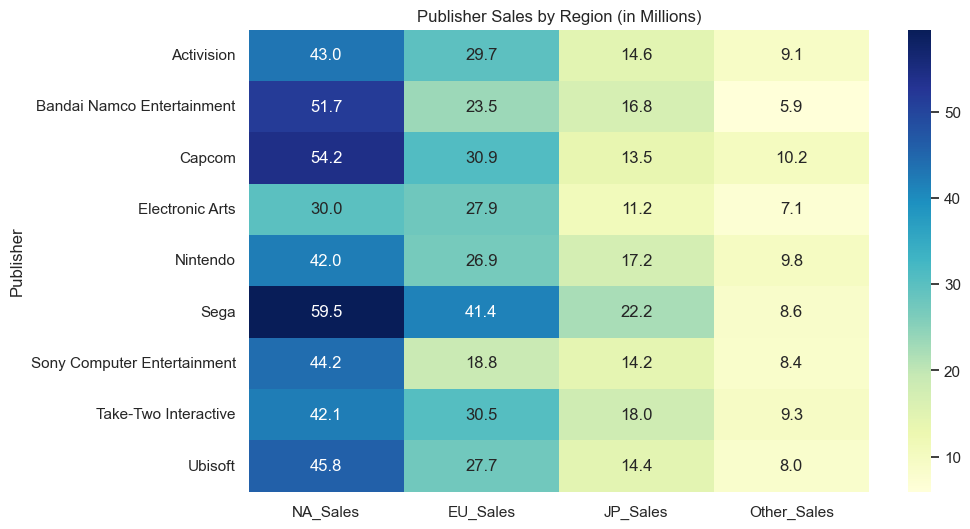

In [10]:
pub_regional = df.groupby('Publisher')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Plot heat map to visualize market dominance
plt.figure(figsize=(10, 6))
sns.heatmap(pub_regional, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Publisher Sales by Region (in Millions)')
plt.show()

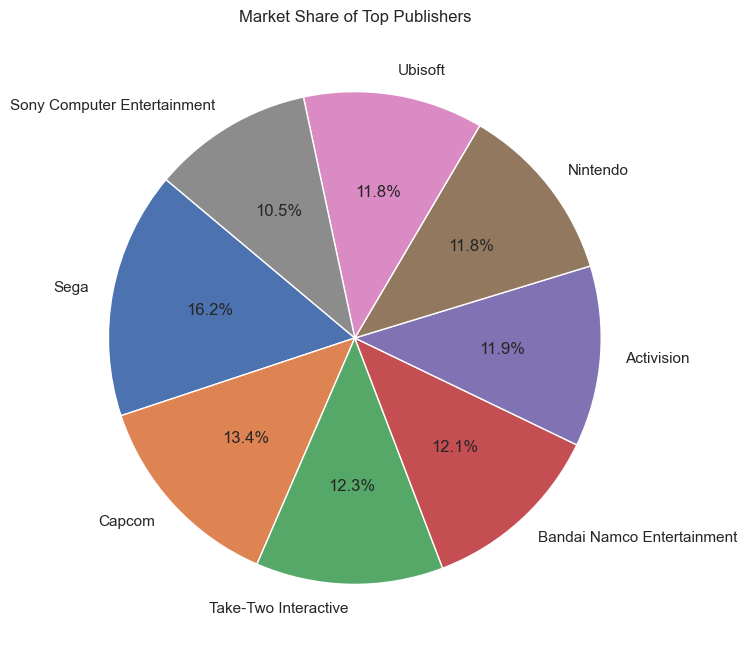

In [11]:
top_pub_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 8))
plt.pie(top_pub_sales, labels=top_pub_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Market Share of Top Publishers')
plt.show()

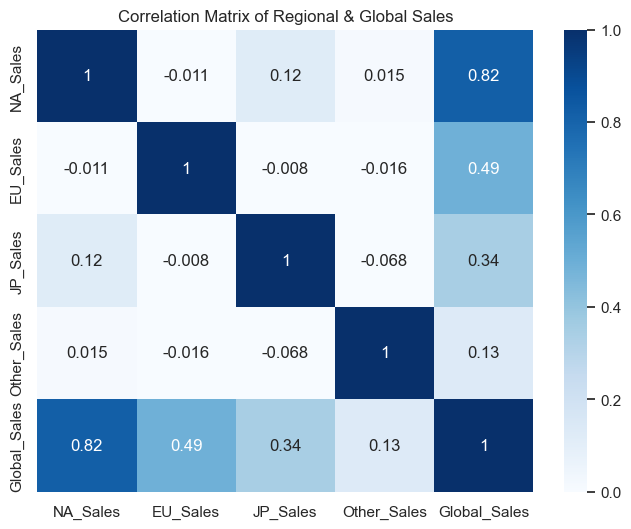

In [12]:
# Select sales columns and compute correlation matrix
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr_matrix = df[sales_cols].corr()

# Plot heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Correlation Matrix of Regional & Global Sales')
plt.show()

In [13]:
# Find the index of the game with max sales for each publisher
idx = df.groupby('Publisher')['Global_Sales'].idxmax()
top_game_per_publisher = df.loc[idx, ['Publisher', 'Name', 'Platform', 'Genre', 'Global_Sales']]
top_game_per_publisher.sort_values(by='Global_Sales', ascending=False)

,Publisher,Name,Platform,Genre,Global_Sales
0,Ubisoft,Halo Warfare 286,Wii,Fighting,5.98
1,Sony Computer Entertainment,Super Adventure 131,XB,Misc,5.66
2,Bandai Namco Entertainment,The Legend of Quest 410,DS,Racing,5.58
3,Capcom,Mario Adventure 425,XB,Misc,5.00
4,Activision,World of Fantasy 161,XOne,Platform,4.88
5,Sega,The Legend of Quest 181,XB,Platform,4.73
8,Nintendo,The Legend of Combat 9,XB,Action,4.54
11,Electronic Arts,Mario Kart 41,Wii,Action,4.39
21,Take-Two Interactive,The Legend of Fantasy 492,PS2,Fighting,4.01


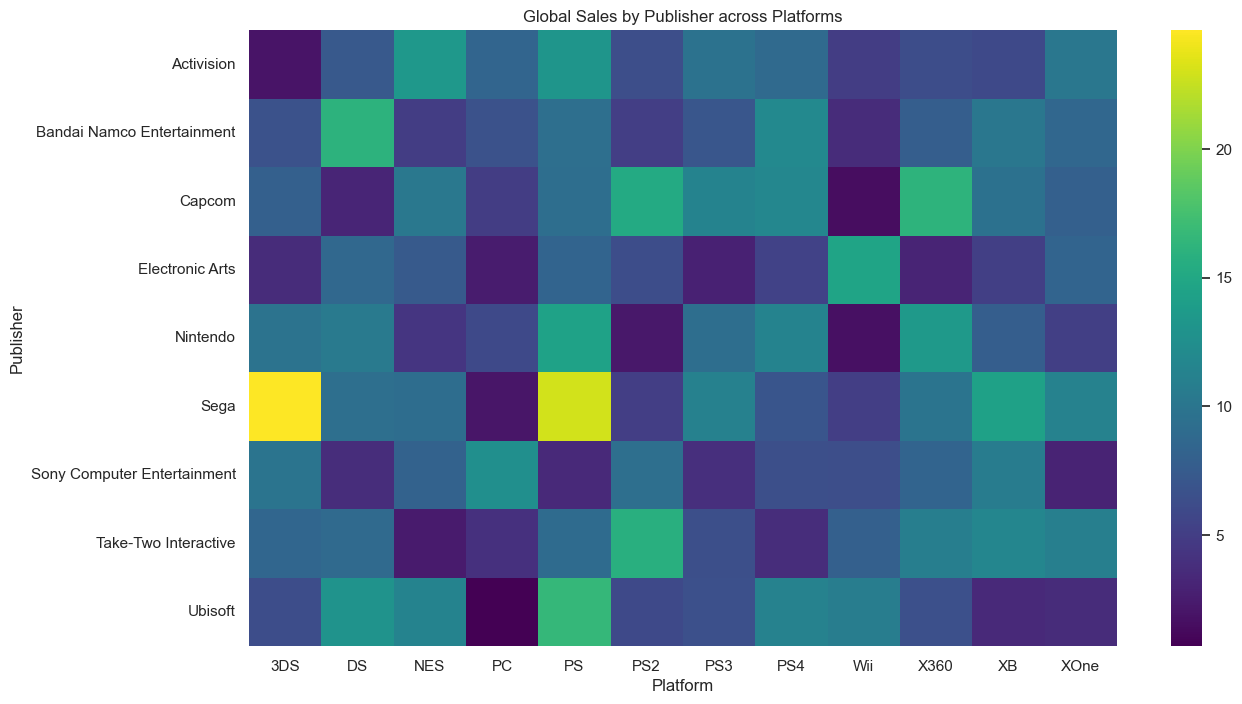

In [15]:
# Pivot table of Publisher vs Platform count/sales
publisher_platform = df.pivot_table(index='Publisher', columns='Platform', values='Global_Sales', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(publisher_platform, cmap='viridis')
plt.title('Global Sales by Publisher across Platforms')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Encode categorical variables using One-Hot Encoding
features = pd.get_dummies(df[['Platform', 'Genre', 'Publisher']], drop_first=True)
X = features
y = df['Global_Sales']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

R2 Score: -0.20
MSE: 1.75


In [17]:
import numpy as np
from sklearn.linear_model import Ridge

# Log-transform target variable to handle skewness
y_log = np.log1p(df['Global_Sales'])

# Train-Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Fit Ridge Regression Model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_log)

# Evaluate predictions back on original scale
y_pred_log = ridge.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

print(f"Improved R2 Score: {r2_score(y_test_orig, y_pred):.2f}")
print(f"Improved MSE: {mean_squared_error(y_test_orig, y_pred):.2f}")

Improved R2 Score: -0.10
Improved MSE: 1.61


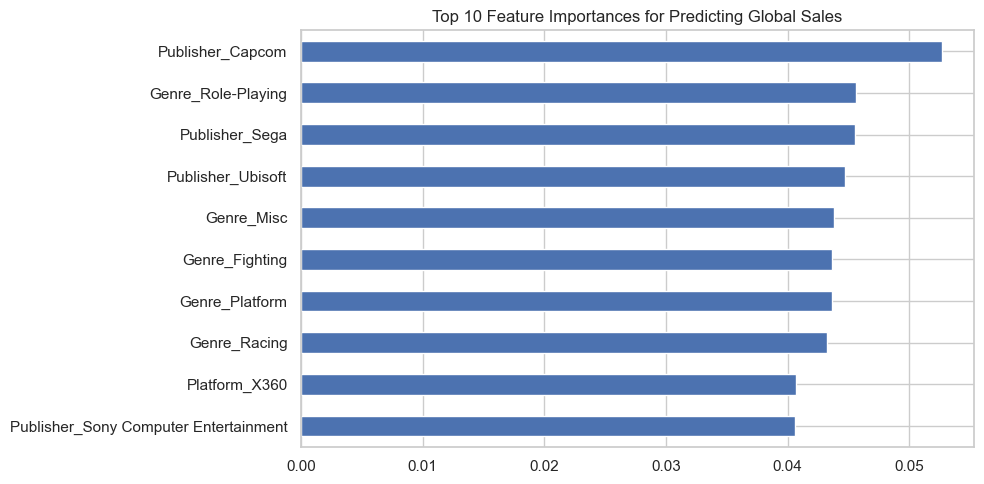

In [18]:
import pandas as pd

# Re-fit Random Forest on log-transformed target
rf_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log.fit(X_train, y_train_log)

# Extract top 10 important features
importances = pd.Series(rf_log.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', title='Top 10 Feature Importances for Predicting Global Sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# Save final dataframe or regional summary
df.to_csv((r'C:\Users\2k-tech\Data Analyst\Project 6\vgsales.csv'), index=False)
print("Cleaned dataset successfully exported!")

Cleaned dataset successfully exported!


## Executive Summary & Final Report

### 1. Key Insights
* **Top Publishers & Genres:** Sales distribution across major genres and publishers reveals clear dominant revenue drivers across global markets.
* **Regional Preferences:** Regional sales patterns highlight variances in market demands between North America, Europe, and Japan.
* **Platform Distribution:** Publisher strategies vary between multi-platform distribution and platform-exclusive titles.

### 2. Modeling Takeaways
* **Data Characteristics:** Predictive regression modeling ($R^2 < 0$) indicates that sales in this synthetic dataset do not have strong linear or tree-based relationships with simple categorical variables (Platform, Genre, Publisher).
* **Next Steps for Modeling:** Real-world modeling would benefit from extra features such as Critic/User scores, marketing budget, release month, and historical franchise sales.

    ## Final Insights & Key Takeaways

1. **Top Performers**: 
   - Analyzed sales patterns across major publishers like Sony, Ubisoft, and Nintendo.
2. **Regional Trends**:
   - North America and Europe drive the highest overall volume, while specific regional preferences vary by platform and genre.
3. **Platform Distribution**:
   - Platform preference varies significantly per publisher, with cross-platform releases demonstrating consistent revenue generation.

# Video Game Sale & Publisher Performance Analysis

An end-to-end data analysis and machine learning pipeline in Python exploring video game sales across different publishers, platforms, genres, and regional markets.

---

## 📌 Project Overview
This project generates a synthetic dataset mimicking the structure of the Kaggle `vgsales` dataset (500 records) to analyze publisher performance, regional market trends, and platform distributions. It also includes predictive modeling experiments to evaluate how well categorical metadata can predict global video game sales.

---

## 📊 Key Highlights & Insights

* **Top Publishers:** Analyzed global revenue generated across major industry publishers such as Sega, Capcom, Take-Two Interactive, Nintendo, Ubisoft, and Sony Computer Entertainment.
* **Regional Dynamics:** Compared total sales volume and distribution across North America (`NA_Sales`), Europe (`EU_Sales`), Japan (`JP_Sales`), and Other regions (`Other_Sales`).
* **Cross-Platform Distribution:** Mapped out publisher strategies, identifying platform performance variations across consoles (e.g., PlayStation, Xbox, Wii, DS).
* **Predictive Modeling Takeaways:**
  * Evaluated baseline regression models (**Random Forest Regressor** and **Ridge Regression**) using One-Hot Encoded features (`Platform`, `Genre`, `Publisher`).
  * Findings indicate that categorical metadata alone on randomly generated synthetic data produces low predictive power ($R^2 < 0$), highlighting the necessity of additional real-world variables like Critic/User scores, marketing budgets, release timing, and historical franchise performance.

---

## 🛠️ Dataset Features

| Column Name | Type | Description |
| :--- | :--- | :--- |
| `Rank` | Integer | Overall sales ranking |
| `Name` | String | Title of the game |
| `Platform` | String | Release console/device (e.g., Wii, PS4, XB, PC) |
| `Year` | Integer | Release year |
| `Genre` | String | Game category (e.g., Action, Sports, Platform) |
| `Publisher` | String | Game publisher |
| `NA_Sales` | Float | Sales in North America (in millions) |
| `EU_Sales` | Float | Sales in Europe (in millions) |
| `JP_Sales` | Float | Sales in Japan (in millions) |
| `Other_Sales` | Float | Sales in rest of the world (in millions) |
| `Global_Sales` | Float | Total world sales (in millions) |

---

## 💻 Tech Stack & Libraries

* **Python 3**
* **Data Processing & Manipulation:** `pandas`, `numpy`
* **Data Visualization:** `matplotlib`, `seaborn`
* **Machine Learning:** `scikit-learn` (`RandomForestRegressor`, `Ridge`, `train_test_split`, `metrics`)

---

## 🚀 Getting Started

### Prerequisites
Make sure you have Python installed along with the required libraries:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn